# 04. Classification Model - Phân loại phân khúc giá Game

## 1. Mục tiêu
Xây dựng mô hình phân loại (Classification) để dự đoán phân khúc giá của game (`price_category`) dựa trên các thành phần PCA. 

Phân loại giúp chúng ta hiểu rõ đặc tính của các nhóm sản phẩm khác nhau trên Steam mà không cần quan tâm đến sai số lẻ của giá tiền.

In [1]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append('../')
from src.models.classification import train_classification_model
from src.evaluation import evaluate_classification
from src.utils import save_model

df_clean = pd.read_csv('../data/processed/clean_data.csv')
df_pca = pd.read_csv('../data/processed/pca_data.csv')

X = df_pca
y = df_clean['price_category'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Số lượng mẫu huấn luyện: {len(X_train)}")
print(f"Số lượng mẫu kiểm tra: {len(X_test)}")

Số lượng mẫu huấn luyện: 191728
Số lượng mẫu kiểm tra: 47932


## 2. Huấn luyện mô hình 
Random Forest

In [2]:
rfc_model = train_classification_model(X_train, y_train, model_type='rfc')
y_pred_rfc = rfc_model.predict(X_test)
rfc_metrics = evaluate_classification(y_test, y_pred_rfc, model_name="Price Category Classifier")

--- Price Category Classifier Classification Metrics ---
Accuracy: 0.9860

Detailed Classification Report:
              precision    recall  f1-score   support

   expensive       0.98      1.00      0.99     28959
        free       0.99      0.97      0.98     18973

    accuracy                           0.99     47932
   macro avg       0.99      0.98      0.99     47932
weighted avg       0.99      0.99      0.99     47932



* **Accuracy (98.6%):** Mô hình dự đoán đúng gần như tuyệt đối phân khúc giá của game. Điều này cho thấy các đặc trưng như số lượng ngôn ngữ, nền tảng và năm phát hành có sự khác biệt rất lớn giữa game miễn phí và game trả phí.
* **Phân tích theo nhãn (Class-wise):**
    * **Expensive (Giá cao):** Đạt Recall tuyệt đối (1.00). Nghĩa là mô hình không bỏ sót bất kỳ game trả phí nào.
    * **Free (Miễn phí):** Đạt Precision cực cao (0.99). Nghĩa là nếu mô hình dự đoán là game Free, thì gần như chắc chắn nó là Free.
* **F1-Score (0.98 - 0.99):** Chỉ số cân bằng giữa Precision và Recall ở mức rất cao, cho thấy mô hình không bị lệch (bias) dù số lượng mẫu giữa hai nhóm có sự chênh lệch (28k vs 19k).

Logistic Regression

In [3]:
lr_model = train_classification_model(X_train, y_train, model_type='whatever')
y_pred_lr = lr_model.predict(X_test)
lr_metrics = evaluate_classification(y_test, y_pred_lr, model_name="Logistic Regression")

--- Logistic Regression Classification Metrics ---
Accuracy: 0.9391

Detailed Classification Report:
              precision    recall  f1-score   support

   expensive       0.91      1.00      0.95     28959
        free       1.00      0.85      0.92     18973

    accuracy                           0.94     47932
   macro avg       0.95      0.92      0.93     47932
weighted avg       0.94      0.94      0.94     47932



 **Accuracy (93.91%):** Kém hơn RandomForest
* **Phân tích theo nhãn (Class-wise):**
    * **Expensive (Giá cao):** Precision 0.91, vẫn có một số game bị đoán lệch, recall = 1 như RandomForest. Hoàn toàn lấy hết game giá cao
    * **Free (Miễn phí):** Đạt Precision cực cao (1). Nghĩa là nếu mô hình dự đoán là game Free, thì chắc chắn nó là Free. Recall thấp hơn khá nhiều (0.85) nghĩa là 15% game free đã bị bỏ sót
* **F1-Score (0.92 - 0.95):** Chỉ số cân bằng giữa Precision và Recall vẫn ở mức rất cao nhưng thấp hơn RandomForest

## 3. Trực quan hóa kết quả
Ma trận nhầm lẫn (Confusion Matrix) sẽ cho thấy mô hình có bị nhầm lẫn giữa các phân khúc giá hay không.

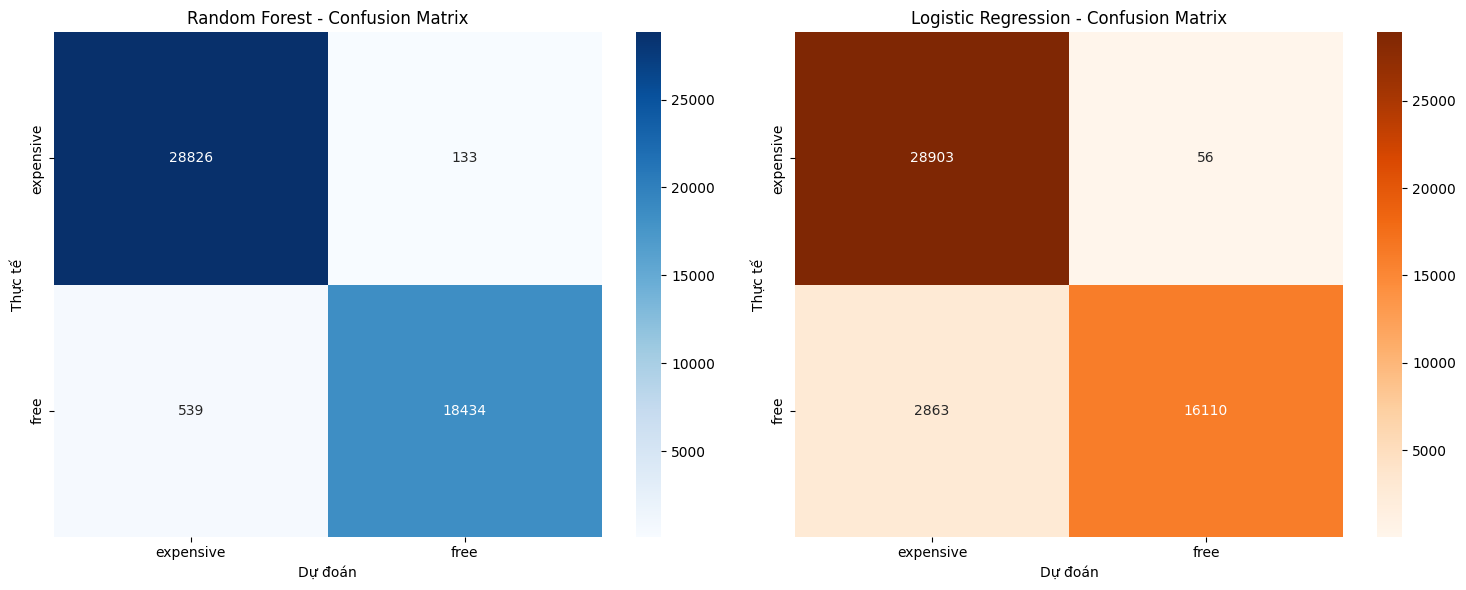

In [4]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rfc = confusion_matrix(y_test, y_pred_rfc)
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rfc_model.classes_, 
            yticklabels=rfc_model.classes_, ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=lr_model.classes_, 
            yticklabels=lr_model.classes_, ax=axes[1])
axes[1].set_title('Logistic Regression - Confusion Matrix')
axes[1].set_ylabel('Thực tế')
axes[1].set_xlabel('Dự đoán')

plt.tight_layout()
plt.show()

Dựa trên các biểu đồ so sánh trực quan, chúng ta có thể thấy rõ bản chất của từng thuật toán:

* **Random Forest (Biểu đồ xanh):** Kiểm soát cực tốt ranh giới phân loại. Lượng mẫu đoán sai rất thấp. Nó chỉ gặp một chút khó khăn nhỏ ở những game vốn là trả phí nhưng đang được sale 100%, hoặc game Indie chất lượng cao nhưng phát hành miễn phí.
* **Logistic Regression (Biểu đồ cam):** Bộc lộ rõ điểm yếu khi cố gắng dùng một siêu mặt phẳng tuyến tính để chia cắt dữ liệu. Mô hình này đã nhầm lẫn nghiêm trọng khi đoán sai tới 15% số lượng game **Free** thành **Expensive**.
* **Kết luận:** Các tựa game miễn phí nhưng mang bộ thông số "khủng" (như dung lượng cực nặng, hỗ trợ đa nền tảng, nhiều ngôn ngữ) đã dễ dàng đánh lừa được đường ranh giới cứng nhắc của Logistic Regression. Trong khi đó, Random Forest đã học được những quy luật phi tuyến tính phức tạp và "bắt bài" thành công những trường hợp ngoại lệ này.

In [5]:
best_model = rfc_model
save_model(best_model, '../src/models/classification.pkl')

Model saved to ../src/models/classification.pkl
